<a href="https://colab.research.google.com/github/riminipa16/CodeAlpha_Heart_disease_Prediction/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
import joblib
import shap
import warnings
!pip install ucimlrepo
warnings.filterwarnings('ignore')
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns


RND = 42

In [9]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

# metadata
print(heart_disease.metadata)

# variable information
print(heart_disease.variables)


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

In [10]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (303, 13)
y shape: (303, 1)


In [11]:
# Look at first rows
print(X.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  


In [12]:
# Check target distribution
print("Target distribution:\n", y.value_counts())

Target distribution:
 num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64


In [13]:
# Check missing values
print("Missing values:\n", X.isnull().sum())

Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [14]:
y = (y > 0).astype(int)
print(y.value_counts())


num
0      164
1      139
Name: count, dtype: int64


In [15]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numeric:", numeric_features)
print("Categorical:", cat_features)


Numeric: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Categorical: []


In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', cat_transformer, cat_features)
    ])


In [18]:
models = {
    'LogisticRegression': (LogisticRegression(max_iter=1000, random_state=RND), {
        'clf__C': [0.1, 1, 10]
    }),
    'SVM': (SVC(probability=True, random_state=RND), {
        'clf__C': [0.1, 1, 10],
        'clf__kernel': ['rbf', 'linear']
    }),
    'RandomForest': (RandomForestClassifier(random_state=RND), {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [None, 5, 10]
    }),
    'XGBoost': (xgb.XGBClassifier(random_state=RND), {
        'clf__n_estimators': [100, 300],
        'clf__max_depth': [3, 6],
        'clf__learning_rate': [0.01, 0.1]
    })
}


In [19]:
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True)
}


In [20]:
def run_grid_search(model_name, model_tuple):
    model, param_grid = model_tuple

    pipe = Pipeline(steps=[
        ('pre', preprocessor),
        ('clf', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

    grid = GridSearchCV(pipe, param_grid=param_grid, scoring='roc_auc', cv=cv)
    grid.fit(X, y.values.ravel())

    print(f"Best {model_name}: {grid.best_score_:.3f}")
    print("Best Parameters:", grid.best_params_)

    results = cross_validate(grid.best_estimator_, X, y.values.ravel(), cv=cv, scoring=scoring)
    print({k: v.mean() for k, v in results.items()})

    return grid.best_estimator_


In [21]:
best_lr = run_grid_search('Logistic Regression', models['LogisticRegression'])


Best Logistic Regression: 0.912
Best Parameters: {'clf__C': 0.1}
{'fit_time': np.float64(0.024469804763793946), 'score_time': np.float64(0.047394323348999026), 'test_accuracy': np.float64(0.8414207650273223), 'test_precision': np.float64(0.8491498097105292), 'test_recall': np.float64(0.7984126984126985), 'test_f1': np.float64(0.82134282443179), 'test_roc_auc': np.float64(nan)}


In [22]:
best_svm = run_grid_search('SVM', models['SVM'])
best_rf  = run_grid_search('RandomForest', models['RandomForest'])
best_xgb = run_grid_search('XGBoost', models['XGBoost'])


Best SVM: 0.910
Best Parameters: {'clf__C': 1, 'clf__kernel': 'linear'}
{'fit_time': np.float64(0.022121238708496093), 'score_time': np.float64(0.014608144760131836), 'test_accuracy': np.float64(0.8348633879781421), 'test_precision': np.float64(0.8367112597547379), 'test_recall': np.float64(0.7984126984126985), 'test_f1': np.float64(0.8152620184263186), 'test_roc_auc': np.float64(nan)}
Best RandomForest: 0.912
Best Parameters: {'clf__max_depth': 10, 'clf__n_estimators': 300}
{'fit_time': np.float64(0.47034058570861814), 'score_time': np.float64(0.03339109420776367), 'test_accuracy': np.float64(0.8217486338797814), 'test_precision': np.float64(0.8318964449399232), 'test_recall': np.float64(0.7695767195767196), 'test_f1': np.float64(0.7987469216769993), 'test_roc_auc': np.float64(nan)}
Best XGBoost: 0.899
Best Parameters: {'clf__learning_rate': 0.01, 'clf__max_depth': 6, 'clf__n_estimators': 300}
{'fit_time': np.float64(0.11937294006347657), 'score_time': np.float64(0.016144943237304688)

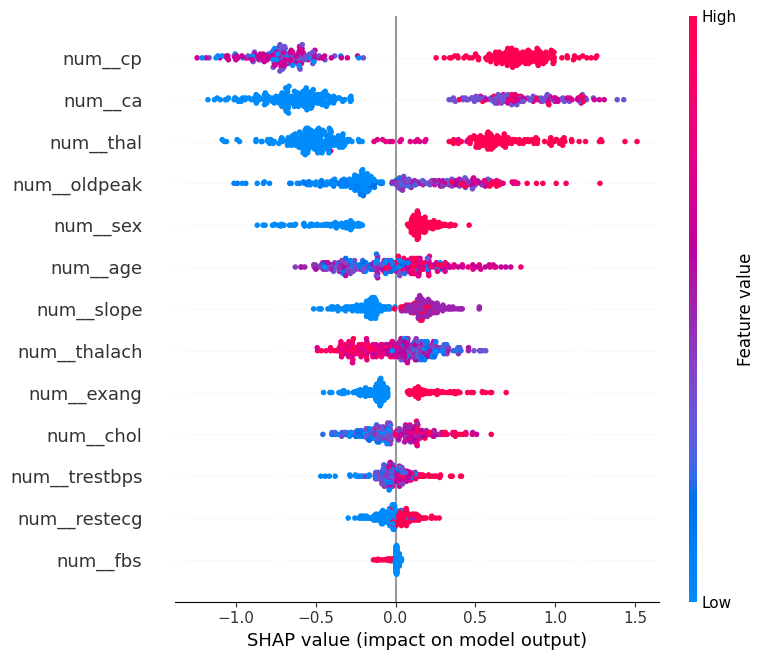

In [23]:
import shap

# prepare the data after preprocessing
pre = best_xgb.named_steps['pre']
X_pre = pre.transform(X)

clf = best_xgb.named_steps['clf']

explainer = shap.Explainer(clf)
shap_values = explainer(X_pre)

shap.summary_plot(shap_values, feature_names=pre.get_feature_names_out())


In [33]:
def train_with_smote(model_name, model_tuple):
    model, param_grid = model_tuple

    pipe = ImbPipeline(steps=[
        ('pre', preprocessor),          # numeric/categorical preprocessing
        ('smote', SMOTE(random_state=RND)),
        ('clf', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RND)

    grid = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring='roc_auc',
        cv=cv
    )

    grid.fit(X, y.values.ravel())

    print(f"Best {model_name} ROC-AUC: {grid.best_score_:.3f}")
    print("Best Parameters:", grid.best_params_)

    # Predictions
    y_pred = grid.predict(X)
    y_proba = grid.predict_proba(X)[:, 1]

    print("\nClassification Report:\n")
    print(classification_report(y, y_pred))

    # Visual Metrics
    plot_confusion_matrix(y, y_pred, model_name)
    plot_roc_curve(y, y_proba, model_name)
    plot_precision_recall(y, y_proba, model_name)

    return grid.best_estimator_


In [34]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {title}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [35]:
def plot_roc_curve(y_true, y_proba, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0,1], [0,1], 'k--')
    plt.title(f'ROC Curve - {title}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.show()


In [36]:
def plot_precision_recall(y_true, y_proba, title):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)

    plt.figure(figsize=(5,4))
    plt.plot(recall, precision)
    plt.title(f'Precision-Recall Curve - {title}')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.show()


Best Logistic Regression ROC-AUC: 0.914
Best Parameters: {'clf__C': 0.1}

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       164
           1       0.85      0.80      0.82       139

    accuracy                           0.84       303
   macro avg       0.84      0.84      0.84       303
weighted avg       0.84      0.84      0.84       303



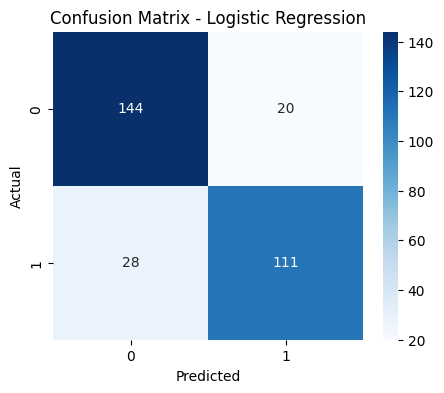

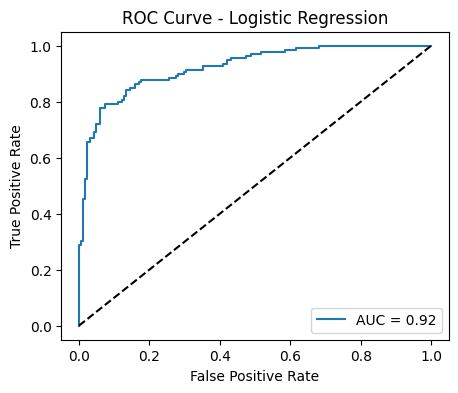

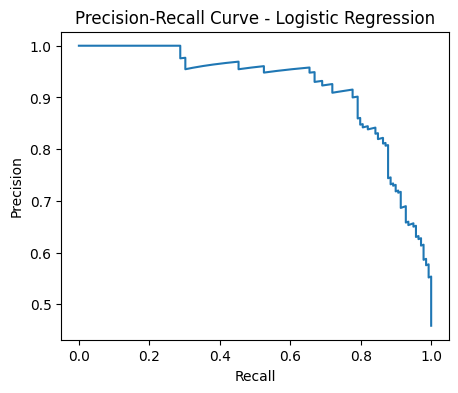

Best SVM ROC-AUC: 0.908
Best Parameters: {'clf__C': 0.1, 'clf__kernel': 'linear'}

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       164
           1       0.86      0.80      0.83       139

    accuracy                           0.85       303
   macro avg       0.85      0.84      0.85       303
weighted avg       0.85      0.85      0.85       303



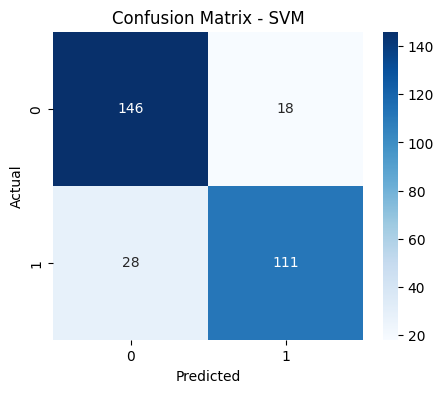

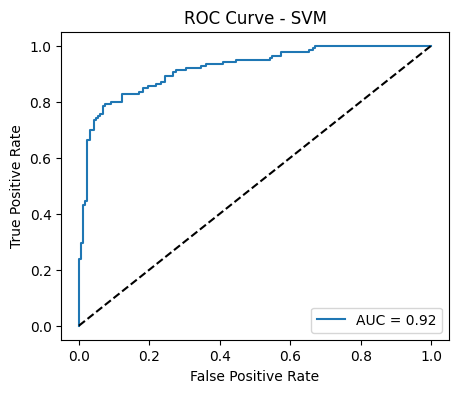

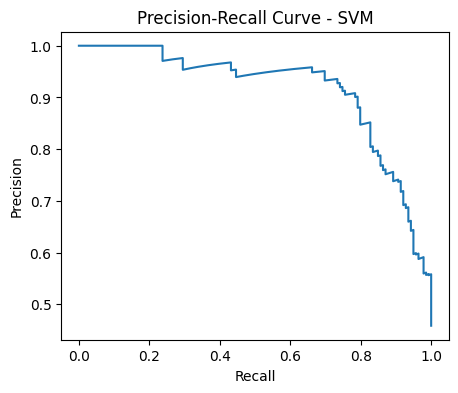

Best Random Forest ROC-AUC: 0.917
Best Parameters: {'clf__max_depth': 5, 'clf__n_estimators': 300}

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       164
           1       0.96      0.88      0.92       139

    accuracy                           0.93       303
   macro avg       0.93      0.93      0.93       303
weighted avg       0.93      0.93      0.93       303



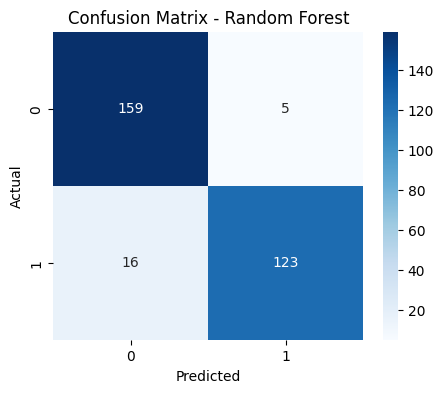

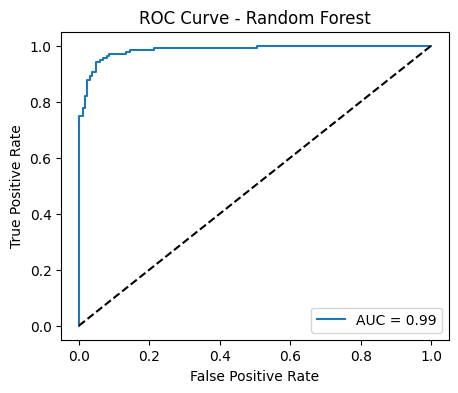

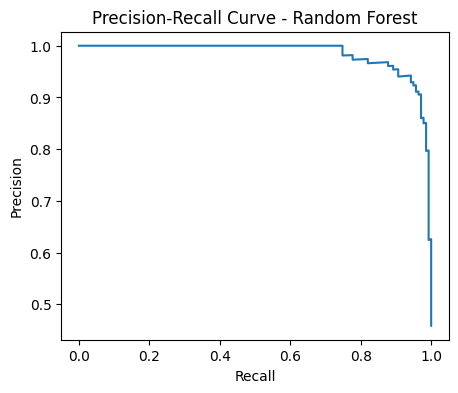

Best XGBoost ROC-AUC: 0.903
Best Parameters: {'clf__learning_rate': 0.01, 'clf__max_depth': 3, 'clf__n_estimators': 300}

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       164
           1       0.91      0.84      0.88       139

    accuracy                           0.89       303
   macro avg       0.89      0.89      0.89       303
weighted avg       0.89      0.89      0.89       303



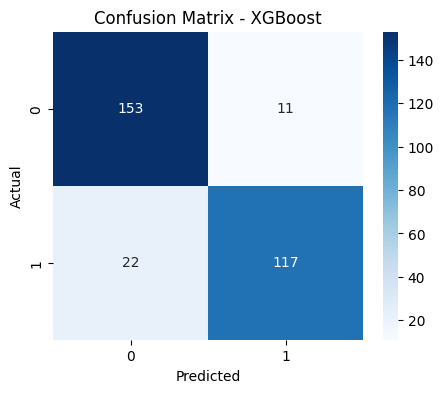

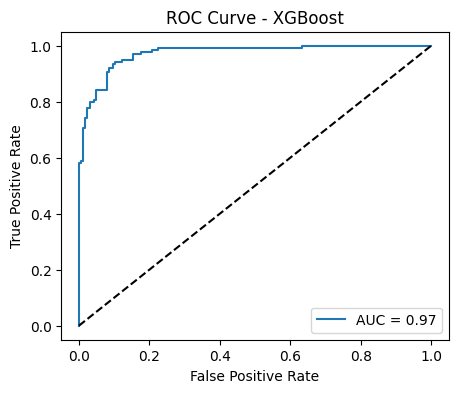

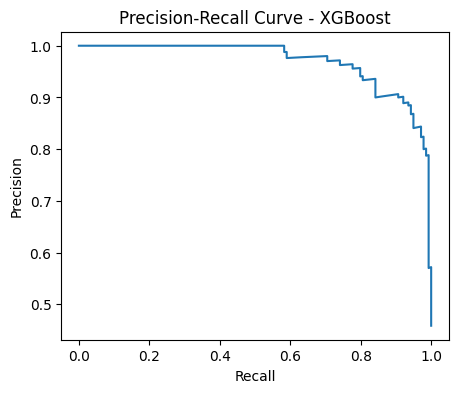

In [37]:
best_lr  = train_with_smote('Logistic Regression', models['LogisticRegression'])
best_svm = train_with_smote('SVM', models['SVM'])
best_rf  = train_with_smote('Random Forest', models['RandomForest'])
best_xgb = train_with_smote('XGBoost', models['XGBoost'])
